# Dependencias y constantes

In [52]:
# Import de librerías importantes
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt
import pandas as pd
import itertools as it

# Librerías utilizadas en algunos análisis
from scipy.stats import linregress                  # Para el análisis de regresión lineal
from scipy.stats import friedmanchisquare, f_oneway # Para el test Friedman y ANOVA
from scipy.stats import wilcoxon                    # Para el test de Wilcoxon     
from sklearn.linear_model import LinearRegression   # Para la regresión lineal múltiple
from sklearn import tree                            # Para la creación de árboles de decisión
from sklearn.ensemble import RandomForestRegressor  # Para la creación de bosques aleatorios (random forest)
from sklearn.neural_network import MLPRegressor     # Para la creación de redes neuronales de perceptrones
import lightgbm as lgb                              # Para la creación de modelos regresores LightGBM


# Para poder cargar los módulos escritos en la raíz del proyecto
from pathlib import Path
import sys

RAIZ_PROYECTO = Path().resolve().parent
sys.path.insert(0, str(RAIZ_PROYECTO))

import src.estadistica as est
import src.representacion as rep
import src.utils as ut

# Para poder recargar los módulos sin tener que reiniciar el kernel
import importlib
importlib.reload(est)
importlib.reload(rep)
importlib.reload(ut)

R_DATAFRAME = "../datos/out/df_long.csv"            # Ruta del dataframe en csv
DIR_SALIDA = "../salida/estudio_disposiciones/"     # Directorio de salida de los resultados

SEMILLA = 1905                                      # Semilla para la generación de números aleatorios
PROPORCION_TEST = 0.3                               # Proporción de datos que se utilizarán para el conjunto de test
COLUMNA_P = "Pdc"                                   # Nombre de la columna que contiene los valores de potencia

FUNCION_ACTIVACION = "relu"                         # Función de activación para la red neuronal de perceptrones
FUNCION_SOLUCION = "adam"                           # Función de optimización para la red neuronal de perceptrones
MAX_ITERACIONES_RN = 1000                           # Número máximo de iteraciones para la red neuronal de perceptrones
MAX_ITERACIONES_ESTANCAMIENTO_RN = 10               # Número máximo de iteraciones sin mejora para la red neuronal de perceptrones

In [53]:
# Funciones muy utilizadas en el cuaderno
def dataframe():
    """Función para cargar el dataframe desde el csv y convertir la columna Datetime a formato datetime."""
    df = pd.read_csv(R_DATAFRAME, parse_dates=['Datetime'])
    return df

# Cuaderno de estudio de configuración de placas

Este cuaderno Jupyter busca comprobar el peso de distintas configuraciones en la disposición de las placas respecto a la potencia que son capaces de generar.

## Comprobación del impacto de la configuración

Uno de los objetivos de este estudio es comprobar si la configuración de las placas tienen un impacto significativo en la potencia generada. Para comprobarlo, se compararán distintas configuraciones y se analizarán los resultados obtenidos.

### Impacto de la posición de las placas

En la planta experimental se encuentran tres posiciones en las que las placas se pueden encontrar instaladas:
1. La izquierda (al este) del grupo.
2. La derecha (al oeste) del grupo.
3. En el centro del grupo.

Esta sección buscará la importancia de la posición de las placas comparando los resultados obtenidos en cada una de las posiciones.

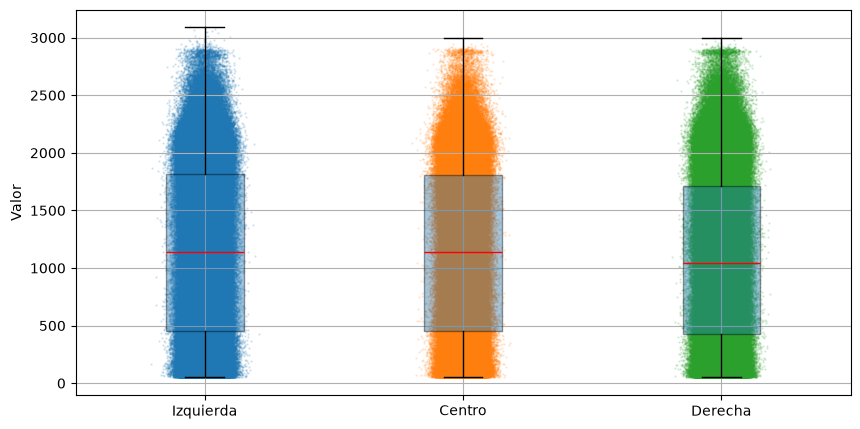

Interpretación del resultado:
- Los p-valores de los test de normalidad son {'Izquierda': 0.01, 'Centro': 0.01, 'Derecha': 0.01}, lo que indica que las series no siguen una distribución normal.
- El p-valor de la prueba de equivalencia es 0.00000, lo que indica que hay diferencias significativas entre las series.
- El estadístico del test es 94140.80948.
- La tabla de diferencias de medias entre las series es:
           Izquierda     Centro    Derecha
Serie                                     
Izquierda   0.000000   1.293790  65.411313
Centro     -1.293790   0.000000  64.060191
Derecha   -65.411313 -64.060191   0.000000
- La tabla de diferencias porcentuales entre las series es:
           Izquierda    Centro   Derecha
Serie                                   
Izquierda   0.000000  0.113440  5.864553
Centro      0.113440  0.000000  5.751172
Derecha     5.864553  5.751172  0.000000
- Para cada serie, la media de diferencias respecto a las demás es:
Serie
Izquierda    22.235034
Centro   

In [32]:
df = dataframe()
resultado = est.interpretar_diferencias_series(est.evaluar_diferencias_series(df, variable=COLUMNA_P, nombres_series=["Izquierda", "Centro", "Derecha"], variables_ficticias=["Disp_Izq", "Disp_Cent", "Disp_Der"]))
ut.guardar_tabla_latex(resultado['tabla_diferencias_medias'], f"{DIR_SALIDA}/posicion_en_grupo/tabla_diferencias_posiciones.tex", "Diferencias de potencia entre las posiciones de las placas (en W)", "tab:diferencias_placas_pos_en_grupo")

### Impacto del número de caras

En el grupo 5 observamos dos tipos de placas: bifaciales y monofaciales.

Es de esperar que las placas bifaciales generarán más potencia pero debemos comprobarlo. Para ello, llevamos a cabo el mismo proceso que utilizamos para comprobar qué posición en el grupo tenía mejor potencial.

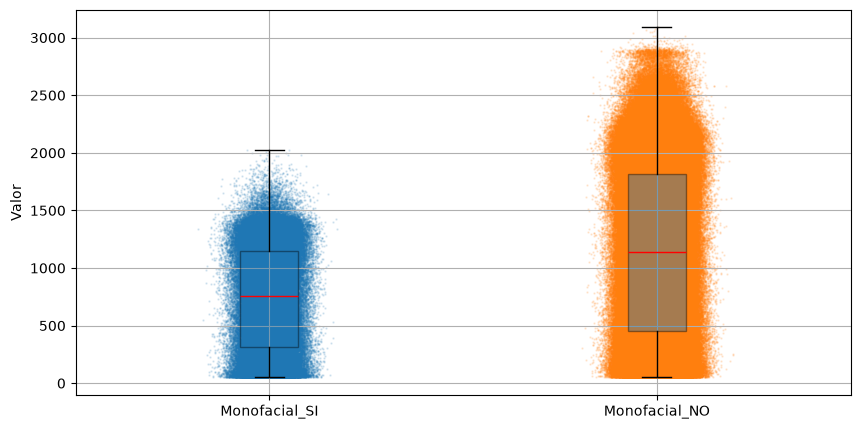

Interpretación del resultado:
- Los p-valores de los test de normalidad son {'Monofacial_SI': 0.01, 'Monofacial_NO': 0.01}, lo que indica que las series no siguen una distribución normal.
- El p-valor de la prueba de equivalencia es 0.00000, lo que indica que hay diferencias significativas entre las series.
- El estadístico del test es 550753523.50000.
- La tabla de diferencias de medias entre las series es:
               Monofacial_SI  Monofacial_NO
Serie                                      
Monofacial_SI       0.000000    -454.151044
Monofacial_NO     454.151044       0.000000
- La tabla de diferencias porcentuales entre las series es:
               Monofacial_SI  Monofacial_NO
Serie                                      
Monofacial_SI       0.000000      47.052048
Monofacial_NO      47.052048       0.000000
- Para cada serie, la media de diferencias respecto a las demás es:
Serie
Monofacial_SI   -227.075522
Monofacial_NO    227.075522
dtype: float64
- La serie dominante es 'Monofa

In [33]:
df = dataframe()
resultados = est.interpretar_diferencias_series(est.evaluar_diferencia_variable_on_off(df, variable=COLUMNA_P, variable_ficticia="Monofacial", nombre_serie="Monofacial"))
ut.guardar_tabla_latex(resultados['tabla_diferencias_medias'], f"{DIR_SALIDA}/monofacial/tabla_diferencias_monofacial.tex", "Diferencias de potencia entre las placas monofaciales y bifaciales (en W)", "tab:diferencias_placas_monofaciales")

### Impacto de la verticalidad de las plcas

En el grupo 3 las placas se encuentran rotadas a diferencia de las placas de otros grupos, dispuestas verticalmente. Esto podría resultar en una diferencia significativa en la generación de potencia.

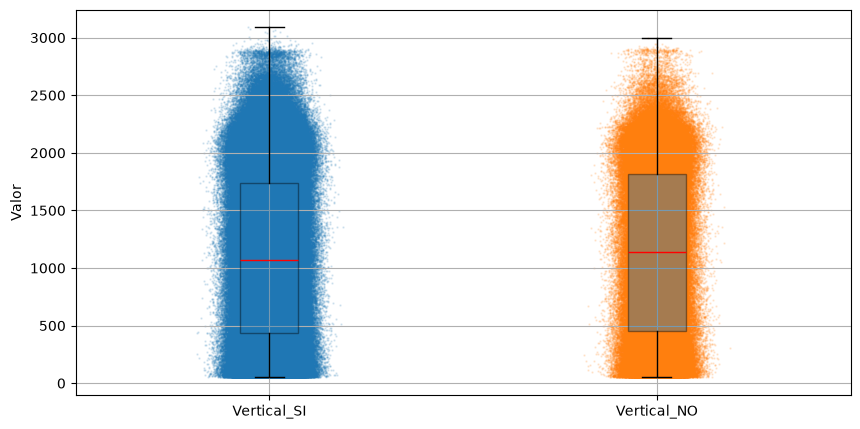

Interpretación del resultado:
- Los p-valores de los test de normalidad son {'Vertical_SI': 0.01, 'Vertical_NO': 0.01}, lo que indica que las series no siguen una distribución normal.
- El p-valor de la prueba de equivalencia es 0.00000, lo que indica que hay diferencias significativas entre las series.
- El estadístico del test es 2555607315791.50000.
- La tabla de diferencias de medias entre las series es:
             Vertical_SI  Vertical_NO
Serie                                
Vertical_SI     0.000000   -51.694862
Vertical_NO    51.694862     0.000000
- La tabla de diferencias porcentuales entre las series es:
             Vertical_SI  Vertical_NO
Serie                                
Vertical_SI     0.000000     4.611156
Vertical_NO     4.611156     0.000000
- Para cada serie, la media de diferencias respecto a las demás es:
Serie
Vertical_SI   -25.847431
Vertical_NO    25.847431
dtype: float64
- La serie dominante es 'Vertical_NO'


In [34]:
df = dataframe()
resultados = est.interpretar_diferencias_series(est.evaluar_diferencia_variable_on_off(df, variable=COLUMNA_P, variable_ficticia="Disp_Vert", nombre_serie="Vertical"))
ut.guardar_tabla_latex(resultados['tabla_diferencias_medias'], f"{DIR_SALIDA}/vertical/tabla_diferencias_vertical.tex", "Diferencias de potencia entre las placas verticales y horizontales (en W)", "tab:diferencias_placas_vertical")

### Comprobación del mejor grupo

Sabiendo que existen diferencias en la generación de potencia cuando las placas se configuran de determinadas formas, podemos estudiar cuál es la mejor configuración de las cinco instaladas en la planta.

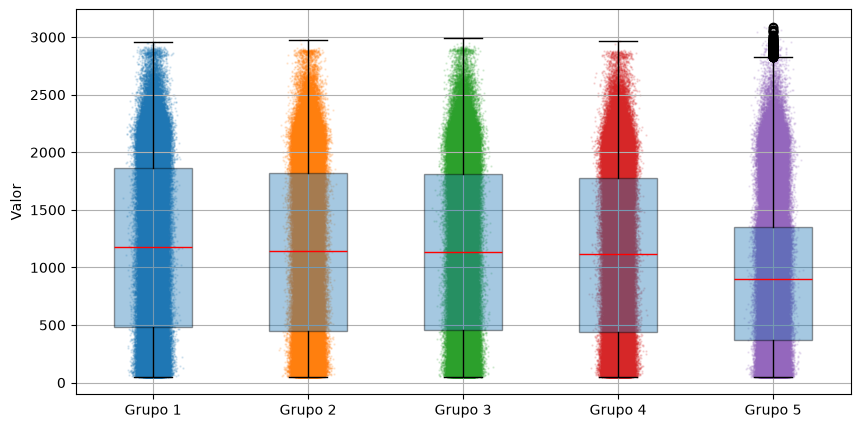

Interpretación del resultado:
- Los p-valores de los test de normalidad son {'Grupo 1': 0.01, 'Grupo 2': 0.01, 'Grupo 3': 0.01, 'Grupo 4': 0.01, 'Grupo 5': 0.01}, lo que indica que las series no siguen una distribución normal.
- El p-valor de la prueba de equivalencia es 0.00000, lo que indica que hay diferencias significativas entre las series.
- El estadístico del test es 17982535.37955.
- La tabla de diferencias de medias entre las series es:
            Grupo 1     Grupo 2     Grupo 3     Grupo 4     Grupo 5
Serie                                                              
Grupo 1    0.000000   36.202104   38.373009   59.296697  270.231099
Grupo 2  -36.202104    0.000000    2.276387   23.168169  234.068717
Grupo 3  -38.373009   -2.276387    0.000000   20.876009  231.786677
Grupo 4  -59.296697  -23.168169  -20.876009    0.000000  210.336802
Grupo 5 -270.231099 -234.068717 -231.786677 -210.336802    0.000000
- La tabla de diferencias porcentuales entre las series es:
           Gru

In [35]:
df = dataframe()

# Creo una variable por cada grupo para esta prueba
for i in range(1,6):
    df[f"G{i}"] = df["Grupo"].apply(lambda x: 1 if x == i else 0)

resultados = est.interpretar_diferencias_series(est.evaluar_diferencias_series(df, variable=COLUMNA_P, nombres_series=["Grupo 1", "Grupo 2", "Grupo 3", "Grupo 4", "Grupo 5"], variables_ficticias=["G1", "G2", "G3", "G4", "G5"]))
ut.guardar_tabla_latex(resultados['tabla_diferencias_medias'], f"{DIR_SALIDA}/vertical/tabla_diferencias_grupo.tex", "Diferencias de potencia entre grupos (en W)", "tab:diferencias_placas_grupo")

## Predicción de la potencia generada

Sabiendo que todas estas variables tienen un impacto significativo sobre la potencia generada, podemos intentar predecir el valor de la lectura para una configuración concreta de las placas.

In [30]:
df = dataframe()

# Convierto la columna Datetime a numérico para poder utilizarla en la regresión lineal múltiple
df["Datetime"] = df["Datetime"].apply(lambda x: x.timestamp())

# Creo una variable por cada grupo para esta prueba
for i in range(1,6):
    df[f"G{i}"] = df["Grupo"].apply(lambda x: 1 if x == i else 0)

lista_variables = ["Datetime", "Disp_Izq", "Disp_Cent", "Disp_Der", "Monofacial", "Disp_Vert", "G1", "G2", "G3", "G4", "G5", "Temperatura_placas", "Irradiancia"]

filas = []                         # Lista para almacenar los resultados de cada combinación de variables

Regresión lineal múltiple:
Interpretación del resultado:
- El p-valor del test de normalidad es 0.01000, lo que indica que las diferencias no siguen una distribución normal.
- El sesgo entre las dos series es de -0.07427 W, lo que indica que en promedio, una serie tiende a ser 0.07427 W menor que la otra.
- Los límites de acuerdo son [-289.12242, 288.97388] W, lo que indica el rango en el que se espera que caigan el 95% de las diferencias entre las dos series.
- El margen de error para el sesgo es de 0.34410 W, lo que indica la precisión con la que se ha estimado el sesgo.
- La línea de igualdad (y=0) está dentro del intervalo de confianza del sesgo, por lo que el sesgo no es estadísticamente significativo.


/home/jcarvic/Documentos/Universidad/Extracurriculares/codigo/.venv/lib64/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


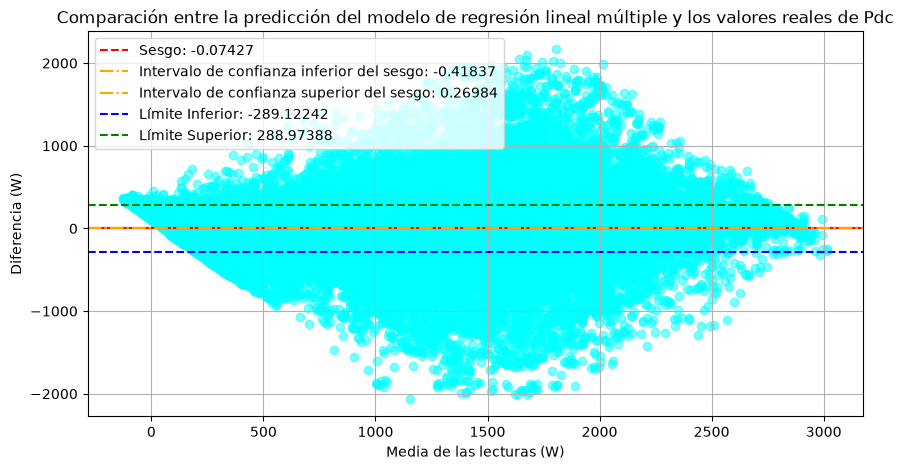

Mejores hiperparámetros encontrados para Regresión lineal múltiple:
{'copy_X': True, 'fit_intercept': True, 'n_jobs': -1, 'positive': False, 'tol': 1e-06}
Fila de resultados para Regresión lineal múltiple:
                      Método        RMSE        MAE       MAPE     MDAPE
0  Regresión lineal múltiple  144.523986  86.463451  22.005434  5.934455


In [31]:
# region Regresión lineal múltiple
modelo_reg_lin = LinearRegression()
param_grid = {'fit_intercept': [True, False]}

fila_reg_lin = ut.realizar_prueba_regresor(modelo_reg_lin, df, COLUMNA_P, lista_variables, param_grid, SEMILLA, PROPORCION_TEST, "Regresión lineal múltiple", f"{DIR_SALIDA}resultados_test_reg_lin.csv", "W")

filas.append(fila_reg_lin)
# endregion

Árbol CART:
Probando hiperparámetros para Árbol CART:
{'ccp_alpha': [0.0], 'criterion': ['squared_error'], 'max_depth': [20], 'min_impurity_decrease': [0.0], 'min_samples_leaf': [1], 'min_samples_split': [2], 'min_weight_fraction_leaf': [0.0], 'random_state': [1905], 'splitter': ['random']}


/home/jcarvic/Documentos/Universidad/Extracurriculares/codigo/.venv/lib64/python3.14/site-packages/sklearn/model_selection/_search.py:326: UserWarning: The total space of parameters 1 is smaller than n_iter=158121. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Mejores hiperparámetros encontrados para Árbol CART: {'splitter': 'random', 'random_state': 1905, 'min_weight_fraction_leaf': 0.0, 'min_samples_split': 2, 'min_samples_leaf': 1, 'min_impurity_decrease': 0.0, 'max_depth': 20, 'criterion': 'squared_error', 'ccp_alpha': 0.0}
Interpretación del resultado:
- El p-valor del test de normalidad es 0.01000, lo que indica que las diferencias no siguen una distribución normal.
- El sesgo entre las dos series es de 0.09567 W, lo que indica que en promedio, una serie tiende a ser 0.09567 W mayor que la otra.
- Los límites de acuerdo son [-228.90918, 229.10051] W, lo que indica el rango en el que se espera que caigan el 95% de las diferencias entre las dos series.
- El margen de error para el sesgo es de 0.27262 W, lo que indica la precisión con la que se ha estimado el sesgo.
- La línea de igualdad (y=0) está dentro del intervalo de confianza del sesgo, por lo que el sesgo no es estadísticamente significativo.


/home/jcarvic/Documentos/Universidad/Extracurriculares/codigo/.venv/lib64/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


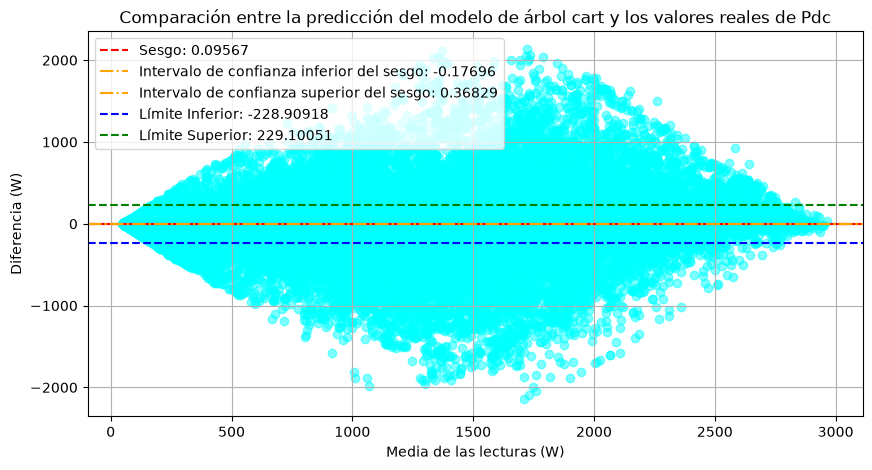

Mejores hiperparámetros encontrados para Árbol CART:
{'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 20, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 1905, 'splitter': 'random'}
Fila de resultados para Árbol CART:
       Método        RMSE        MAE      MAPE     MDAPE
0  Árbol CART  114.502376  49.838545  6.989011  2.823713


In [32]:
# region Árbol de decisión
regresor = tree.DecisionTreeRegressor(random_state=SEMILLA)
param_grid = {'splitter': ['best', 'random'], 'max_depth': [5, 10, 20, 50], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}

fila_cart = ut.realizar_prueba_regresor(regresor, df, COLUMNA_P, lista_variables, param_grid, SEMILLA, PROPORCION_TEST, "Árbol CART", f"{DIR_SALIDA}resultados_test_cart.csv", "W")

filas.append(fila_cart)
# endregion

Random Forest:
Probando hiperparámetros para Random Forest:
{'bootstrap': [True], 'ccp_alpha': [0.0], 'criterion': ['squared_error'], 'max_depth': [20], 'max_features': [1.0], 'min_impurity_decrease': [0.0], 'min_samples_leaf': [1], 'min_samples_split': [2], 'min_weight_fraction_leaf': [0.0], 'n_estimators': [100], 'oob_score': [False], 'random_state': [1905], 'verbose': [0], 'warm_start': [False]}


/home/jcarvic/Documentos/Universidad/Extracurriculares/codigo/.venv/lib64/python3.14/site-packages/sklearn/model_selection/_search.py:326: UserWarning: The total space of parameters 1 is smaller than n_iter=158121. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Mejores hiperparámetros encontrados para Random Forest: {'warm_start': False, 'verbose': 0, 'random_state': 1905, 'oob_score': False, 'n_estimators': 100, 'min_weight_fraction_leaf': 0.0, 'min_samples_split': 2, 'min_samples_leaf': 1, 'min_impurity_decrease': 0.0, 'max_features': 1.0, 'max_depth': 20, 'criterion': 'squared_error', 'ccp_alpha': 0.0, 'bootstrap': True}
Interpretación del resultado:
- El p-valor del test de normalidad es 0.01000, lo que indica que las diferencias no siguen una distribución normal.
- El sesgo entre las dos series es de -0.01401 W, lo que indica que en promedio, una serie tiende a ser 0.01401 W menor que la otra.
- Los límites de acuerdo son [-149.79598, 149.76796] W, lo que indica el rango en el que se espera que caigan el 95% de las diferencias entre las dos series.
- El margen de error para el sesgo es de 0.17831 W, lo que indica la precisión con la que se ha estimado el sesgo.
- La línea de igualdad (y=0) está dentro del intervalo de confianza del sesgo

/home/jcarvic/Documentos/Universidad/Extracurriculares/codigo/.venv/lib64/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


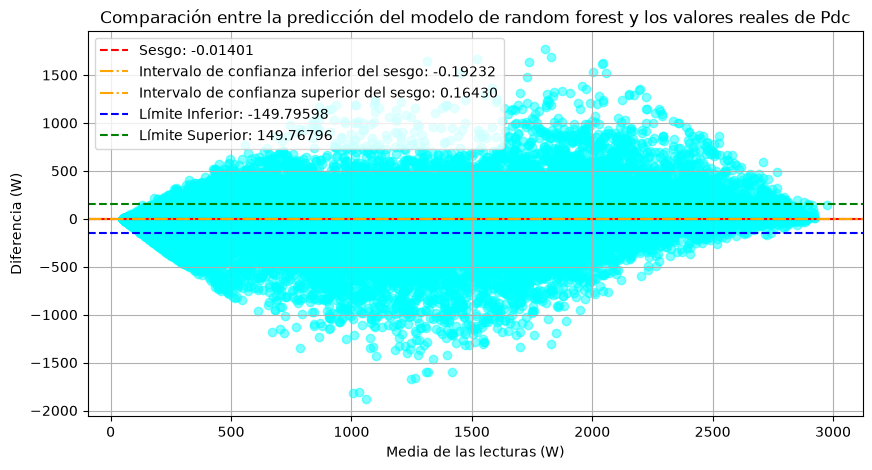

Mejores hiperparámetros encontrados para Random Forest:
{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 20, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 1905, 'verbose': 0, 'warm_start': False}
Fila de resultados para Random Forest:
          Método       RMSE        MAE      MAPE     MDAPE
0  Random Forest  74.890932  33.888343  4.564932  1.991707


In [33]:
# region random forest
regresor = RandomForestRegressor(random_state=SEMILLA)
param_grid = {'n_estimators': [100], 'max_depth': [5, 10, 20, 50], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}

fila_rf = ut.realizar_prueba_regresor(regresor, df, COLUMNA_P, lista_variables, param_grid, SEMILLA, PROPORCION_TEST, "Random Forest", f"{DIR_SALIDA}resultados_test_rf.csv", "W")

filas.append(fila_rf)
# endregion

LightGBM:
Probando hiperparámetros para LightGBM:
{'boosting_type': ['gbdt'], 'colsample_bytree': [1.0], 'importance_type': ['split'], 'learning_rate': [0.2], 'max_depth': [-1], 'min_child_samples': [20], 'min_child_weight': [0.001], 'min_split_gain': [0.0], 'n_estimators': [150], 'num_leaves': [31], 'random_state': [1905], 'reg_alpha': [0.0], 'reg_lambda': [0.0], 'subsample': [1.0], 'subsample_for_bin': [200000], 'subsample_freq': [0], 'verbose': [-1]}


/home/jcarvic/Documentos/Universidad/Extracurriculares/codigo/.venv/lib64/python3.14/site-packages/sklearn/model_selection/_search.py:326: UserWarning: The total space of parameters 1 is smaller than n_iter=158121. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Mejores hiperparámetros encontrados para LightGBM: {'verbose': -1, 'subsample_freq': 0, 'subsample_for_bin': 200000, 'subsample': 1.0, 'reg_lambda': 0.0, 'reg_alpha': 0.0, 'random_state': 1905, 'num_leaves': 31, 'n_estimators': 150, 'min_split_gain': 0.0, 'min_child_weight': 0.001, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.2, 'importance_type': 'split', 'colsample_bytree': 1.0, 'boosting_type': 'gbdt'}
Interpretación del resultado:
- El p-valor del test de normalidad es 0.01000, lo que indica que las diferencias no siguen una distribución normal.
- El sesgo entre las dos series es de 0.00089 W, lo que indica que en promedio, una serie tiende a ser 0.00089 W mayor que la otra.
- Los límites de acuerdo son [-197.39530, 197.39707] W, lo que indica el rango en el que se espera que caigan el 95% de las diferencias entre las dos series.
- El margen de error para el sesgo es de 0.23499 W, lo que indica la precisión con la que se ha estimado el sesgo.
- La línea de igualdad 

/home/jcarvic/Documentos/Universidad/Extracurriculares/codigo/.venv/lib64/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


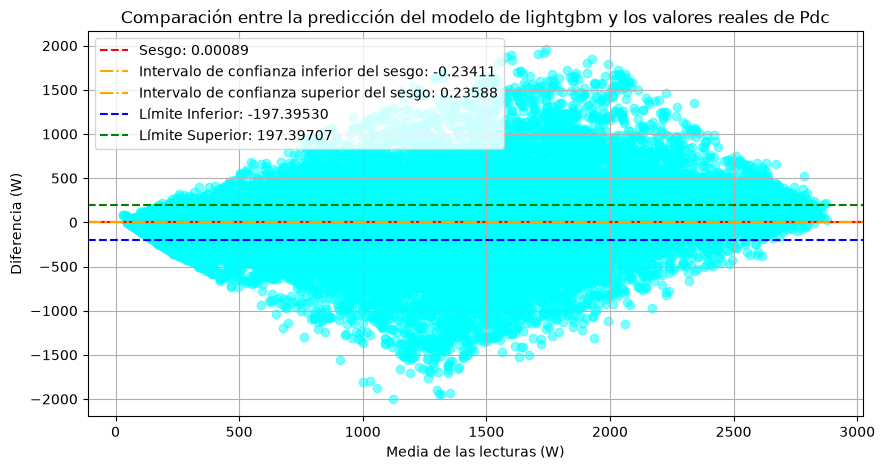

Mejores hiperparámetros encontrados para LightGBM:
{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.2, 'max_depth': -1, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 150, 'n_jobs': None, 'num_leaves': 31, 'objective': None, 'random_state': 1905, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1}
Fila de resultados para LightGBM:
     Método       RMSE        MAE    MAPE     MDAPE
0  LightGBM  98.698021  37.158992  5.8167  1.866757


In [34]:
# Para LightGBM utilizo el día, mes y segundo del día en lugar de datetime pasado a numérico porque es muy sensible a los números desproporcionados y no converge correctamete
df_lgbm = dataframe()

# Paso la columna Datetima a las columnas: día, mes y segundo del día
df_lgbm["Dia"] = df_lgbm["Datetime"].apply(lambda x: x.day)
df_lgbm["Mes"] = df_lgbm["Datetime"].apply(lambda x: x.month)
df_lgbm["Segundo"] = df_lgbm["Datetime"].apply(lambda x: x.hour * 3600 + x.minute * 60 + x.second)

# Creo una variable por cada grupo para esta prueba
for i in range(1,6):
    df_lgbm[f"G{i}"] = df_lgbm["Grupo"].apply(lambda x: 1 if x == i else 0)

lista_variables = ["Dia", "Mes", "Segundo", "Disp_Izq", "Disp_Cent", "Disp_Der", "Monofacial", "Disp_Vert", "G1", "G2", "G3", "G4", "G5", "Temperatura_placas", "Irradiancia"]

# region LightGBM
modelo_lgb = lgb.LGBMRegressor(random_state=SEMILLA, verbose=-1)
param_grid = {
    'num_leaves': [5, 20, 31],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 150]
}

fila_lgb = ut.realizar_prueba_regresor(modelo_lgb, df_lgbm, COLUMNA_P, lista_variables, param_grid, SEMILLA, PROPORCION_TEST, "LightGBM", f"{DIR_SALIDA}resultados_test_lgb.csv", "W")

filas.append(fila_lgb)
# endregion

Red neuronal:
Probando hiperparámetros para Red neuronal:
{'activation': ['relu'], 'alpha': [0.0001], 'batch_size': ['auto'], 'beta_1': [0.9], 'beta_2': [0.999], 'early_stopping': [False], 'epsilon': [1e-08], 'hidden_layer_sizes': [(32, 16)], 'learning_rate': ['constant'], 'learning_rate_init': [0.1], 'loss': ['squared_error'], 'max_fun': [15000], 'max_iter': [1000], 'momentum': [0.9], 'n_iter_no_change': [10], 'nesterovs_momentum': [True], 'power_t': [0.5], 'random_state': [1905], 'shuffle': [True], 'solver': ['adam'], 'tol': [0.0001], 'validation_fraction': [0.1], 'verbose': [False], 'warm_start': [False]}


/home/jcarvic/Documentos/Universidad/Extracurriculares/codigo/.venv/lib64/python3.14/site-packages/sklearn/model_selection/_search.py:326: UserWarning: The total space of parameters 1 is smaller than n_iter=158121. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Mejores hiperparámetros encontrados para Red neuronal: {'warm_start': False, 'verbose': False, 'validation_fraction': 0.1, 'tol': 0.0001, 'solver': 'adam', 'shuffle': True, 'random_state': 1905, 'power_t': 0.5, 'nesterovs_momentum': True, 'n_iter_no_change': 10, 'momentum': 0.9, 'max_iter': 1000, 'max_fun': 15000, 'loss': 'squared_error', 'learning_rate_init': 0.1, 'learning_rate': 'constant', 'hidden_layer_sizes': (32, 16), 'epsilon': 1e-08, 'early_stopping': False, 'beta_2': 0.999, 'beta_1': 0.9, 'batch_size': 'auto', 'alpha': 0.0001, 'activation': 'relu'}
Interpretación del resultado:
- El p-valor del test de normalidad es 0.01000, lo que indica que las diferencias no siguen una distribución normal.
- El sesgo entre las dos series es de 10.48250 W, lo que indica que en promedio, una serie tiende a ser 10.48250 W mayor que la otra.
- Los límites de acuerdo son [-211.87431, 232.83930] W, lo que indica el rango en el que se espera que caigan el 95% de las diferencias entre las dos seri

/home/jcarvic/Documentos/Universidad/Extracurriculares/codigo/.venv/lib64/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


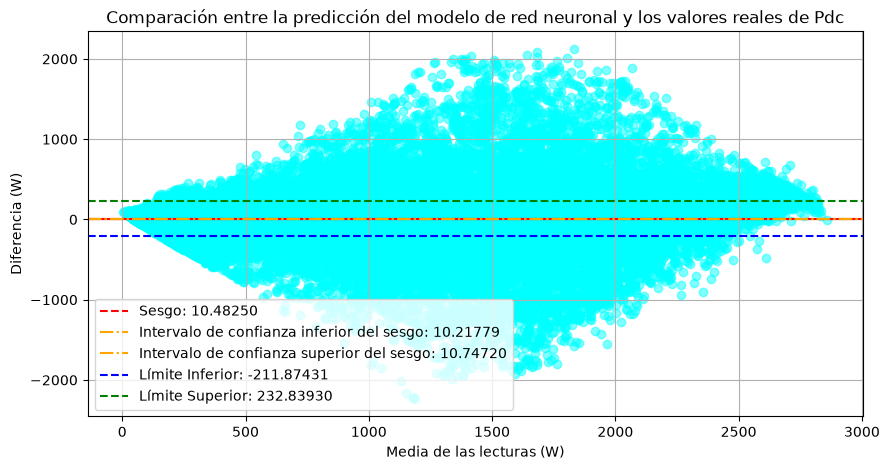

Mejores hiperparámetros encontrados para Red neuronal:
{'activation': 'relu', 'alpha': 0.0001, 'batch_size': 'auto', 'beta_1': 0.9, 'beta_2': 0.999, 'early_stopping': False, 'epsilon': 1e-08, 'hidden_layer_sizes': (32, 16), 'learning_rate': 'constant', 'learning_rate_init': 0.1, 'loss': 'squared_error', 'max_fun': 15000, 'max_iter': 1000, 'momentum': 0.9, 'n_iter_no_change': 10, 'nesterovs_momentum': True, 'power_t': 0.5, 'random_state': 1905, 'shuffle': True, 'solver': 'adam', 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': False, 'warm_start': False}
Fila de resultados para Red neuronal:
         Método        RMSE        MAE      MAPE     MDAPE
0  Red neuronal  111.671401  45.608571  7.793799  2.629087


In [55]:
# Para la red neuronal utilizo un dataframe como el de LightGBM pero normalizo todas las variables para que estén en el rango [0,1] y sea más fácil entrenar
df_rn = dataframe()

# Paso la columna Datetima a las columnas: día, mes y segundo del día
df_rn["Dia"] = df_rn["Datetime"].apply(lambda x: x.day)
df_rn["Mes"] = df_rn["Datetime"].apply(lambda x: x.month)
df_rn["Segundo"] = df_rn["Datetime"].apply(lambda x: x.hour * 3600 + x.minute * 60 + x.second)

# Creo una variable por cada grupo para esta prueba
for i in range(1,6):
    df_rn[f"G{i}"] = df_rn["Grupo"].apply(lambda x: 1 if x == i else 0)

lista_variables = ["Dia", "Mes", "Segundo", "Disp_Izq", "Disp_Cent", "Disp_Der", "Monofacial", "Disp_Vert", "G1", "G2", "G3", "G4", "G5", "Temperatura_placas", "Irradiancia"]

# region red neuronal de perceptrones
modelo_rn = MLPRegressor(random_state=SEMILLA)
param_grid = {
    'hidden_layer_sizes': [
        (8),
        (8, 4),
        (16),
        (16, 8),
        (32),
        (32, 16),
        (32, 16, 8)
    ],
    
    'activation': ['relu'], 
    
    'solver': ['adam'],
    
    'alpha': [0.0001, 0.005, 0.01],
    
    'learning_rate_init': [0.001, 0.01, 0.1, 0.2],
    
    'max_iter': [500, 1000, 2000]
}

fila_rn = ut.realizar_prueba_regresor(modelo_rn, df_rn, COLUMNA_P, lista_variables, param_grid, SEMILLA, PROPORCION_TEST, "Red neuronal", f"{DIR_SALIDA}resultados_test_rn.csv", "W")

filas.append(fila_rn)
# endregion

In [56]:
# Genero la tabla de resultados de las predicciones
print(rep.tabla_diferencias(filas))

\begin{tabular}{lrrrr}
\toprule
\textbf{Método} & \textbf{RMSE} & \textbf{MAE} & \textbf{MAPE} & \textbf{MDAPE} \\
\midrule
Regresión lineal múltiple & 144.523986 & 86.463451 & 22.005434 & 5.934455 \\
Árbol CART & 114.502376 & 49.838545 & 6.989011 & 2.823713 \\
Random Forest & 74.890932 & 33.888343 & 4.564932 & 1.991707 \\
LightGBM & 98.698021 & 37.158992 & 5.816700 & 1.866757 \\
Red neuronal & 111.671401 & 45.608571 & 7.793799 & 2.629087 \\
\bottomrule
\end{tabular}

